# Лабораторна робота №5. Алгоритми пошуку

## Виконав: П'ятибрат Д.С.

## Тема. Алгоритми пошуку
## Мета
Засвоїти варіанти реалізації алгоритмів пошуку (лінійного та бінарного) засобами Python та методи оцінювання їх складності.

In [1]:
# 1. Лінійний пошук
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1

# 2. Бінарний пошук (рекурсивний)
def binary_search(arr, target, left, right):
    if left > right:
        return -1
    mid = (left + right) // 2
    if arr[mid] == target:
        return mid
    elif arr[mid] < target:
        return binary_search(arr, target, mid + 1, right)
    else:
        return binary_search(arr, target, left, mid - 1)

In [2]:
import time
import pandas as pd

def measure_time(search_func, arr, target, is_binary=False):
    start = time.perf_counter()
    if is_binary:
        search_func(arr, target, 0, len(arr)-1)
    else:
        search_func(arr, target)
    return time.perf_counter() - start

sizes = [1000, 5000, 10000, 25000, 50000]
data_lin = []
data_bin = []

for n in sizes:
    arr = list(range(n))
    target = n - 1  # Найгірший випадок
    data_lin.append({"n": n, "time": measure_time(linear_search, arr, target)})
    data_bin.append({"n": n, "time": measure_time(binary_search, arr, target, True)})

df_lin = pd.DataFrame(data_lin)
df_bin = pd.DataFrame(data_bin)
print("Результати лінійного пошуку:\n", df_lin.head())

Результати лінійного пошуку:
        n      time
0   1000  0.000102
1   5000  0.000582
2  10000  0.001042
3  25000  0.002570
4  50000  0.004510


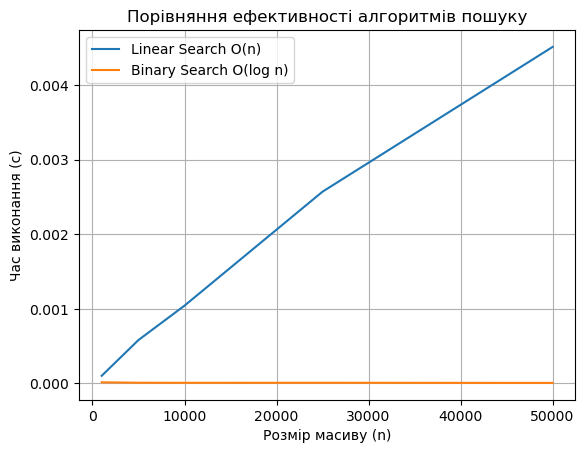

In [3]:
import matplotlib.pyplot as plt

plt.plot(df_lin['n'], df_lin['time'], label='Linear Search O(n)')
plt.plot(df_bin['n'], df_bin['time'], label='Binary Search O(log n)')
plt.xlabel('Розмір масиву (n)')
plt.ylabel('Час виконання (с)')
plt.title('Порівняння ефективності алгоритмів пошуку')
plt.legend()
plt.grid(True)
plt.show()

## Аналіз складності
- **Лінійний пошук:** $O(n)$. У найгіршому випадку потрібно перевірити кожен елемент.
- **Бінарний пошук:** $O(\log n)$. Область пошуку ділиться навпіл на кожному кроці.

## Висновок
Під час роботи я реалізував та порівняв два алгоритми пошуку. Бінарний пошук значно ефективніший для великих відсортованих масивів. Лінійний пошук доцільно використовувати лише для малих або невідсортованих даних.

## Відповіді на контрольні питання
1. **Задача пошуку:** Визначення позиції елемента в структурі даних.
2. **Критерії:** Часова та просторова складність.
3. **Лінійний пошук:** $O(n)$, послідовний перебір.
4. **Бінарний пошук:** $O(\log n)$, базується на принципі "розділяй і володарюй" (працює лише з відсортованими даними).
5. **Переваги:** Бінарний — швидкість, Лінійний — універсальність.